# Export Random Forest Model cho Phát hiện DDoS

**Mục tiêu:**
- Tải và tiền xử lý dữ liệu CIC-DDoS2019
- Huấn luyện mô hình Random Forest
- Export model, scaler và danh sách features để sử dụng trong production

In [1]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Đã import thành công các thư viện!")

Đã import thành công các thư viện!


## 1. Cấu hình đường dẫn và tham số

In [2]:
# Đường dẫn dữ liệu
DATA_PATH = '../Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

# Danh sách đặc trưng cố định
FIXED_FEATURES = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Fwd Packet Length Max',
    'Fwd Packet Length Min',
    'Fwd Packet Length Mean',
    'Fwd Packet Length Std',
    'Bwd Packet Length Max',
    'Bwd Packet Length Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Std',
    'FIN Flag Count',
    'SYN Flag Count',
    'RST Flag Count',
    'Idle Mean',
    'Idle Std',
    'Idle Max',
    'Idle Min'
]

# Các cột cần loại bỏ
COLS_TO_DROP = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']

# Tham số Random Forest
RF_PARAMS = {
    'n_estimators': 100,
    'max_depth': 20,
    'random_state': 42,
    'n_jobs': -1
}

# Tên file export
OUTPUT_DIR = '.'
MODEL_FILE = 'rf_ddos_model.pkl'
SCALER_FILE = 'rf_scaler.pkl'
FEATURES_FILE = 'rf_features.pkl'
LABEL_ENCODER_FILE = 'rf_label_encoder.pkl'

print(f"Dữ liệu sẽ được tải từ: {DATA_PATH}")
print(f"Số đặc trưng sử dụng: {len(FIXED_FEATURES)}")

Dữ liệu sẽ được tải từ: ../Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Số đặc trưng sử dụng: 20


## 2. Tải và kiểm tra dữ liệu

In [3]:
print("Đang tải dữ liệu...")
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f"\nThông tin dữ liệu:")
print(f"- Số dòng: {df.shape[0]:,}")
print(f"- Số cột: {df.shape[1]}")
print(f"\nPhân phối nhãn:")
print(df['Label'].value_counts())

# Hiển thị 5 dòng đầu
print("\n5 dòng đầu tiên:")
display(df.head())

Đang tải dữ liệu...

Thông tin dữ liệu:
- Số dòng: 225,745
- Số cột: 85

Phân phối nhãn:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

5 dòng đầu tiên:

Thông tin dữ liệu:
- Số dòng: 225,745
- Số cột: 85

Phân phối nhãn:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

5 dòng đầu tiên:


,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 3. Tiền xử lý dữ liệu

In [4]:
print("--- BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU ---")

# Loại bỏ các cột định danh
df_processed = df.drop(columns=COLS_TO_DROP, errors='ignore')

# Làm sạch dữ liệu
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Số NaN sau khi thay thế inf: {df_processed.isna().sum().sum()}")

df_processed.dropna(inplace=True)
print(f"Số dòng sau khi loại bỏ NaN: {df_processed.shape[0]:,}")

# Mã hóa nhãn
le = LabelEncoder()
df_processed['Label'] = le.fit_transform(df_processed['Label'])
print(f"\nMapping nhãn: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Lọc các đặc trưng cố định
available_features = [col for col in FIXED_FEATURES if col in df_processed.columns]
missing_features = list(set(FIXED_FEATURES) - set(available_features))

if missing_features:
    print(f"\nCảnh báo: Các đặc trưng sau không tìm thấy: {missing_features}")
else:
    print(f"\nTất cả {len(FIXED_FEATURES)} đặc trưng đều có sẵn!")

df_filtered = df_processed[available_features + ['Label']]

# Tách features và labels
X = df_filtered.drop(columns='Label')
y = df_filtered['Label']

print(f"\nKích thước dữ liệu cuối cùng:")
print(f"- X: {X.shape}")
print(f"- y: {y.shape}")

print("--- KẾT THÚC TIỀN XỬ LÝ ---")

--- BẮT ĐẦU TIỀN XỬ LÝ DỮ LIỆU ---
Số NaN sau khi thay thế inf: 68
Số dòng sau khi loại bỏ NaN: 225,711

Mapping nhãn: {'BENIGN': np.int64(0), 'DDoS': np.int64(1)}

Tất cả 20 đặc trưng đều có sẵn!

Kích thước dữ liệu cuối cùng:
- X: (225711, 20)
- y: (225711,)
--- KẾT THÚC TIỀN XỬ LÝ ---

Mapping nhãn: {'BENIGN': np.int64(0), 'DDoS': np.int64(1)}

Tất cả 20 đặc trưng đều có sẵn!

Kích thước dữ liệu cuối cùng:
- X: (225711, 20)
- y: (225711,)
--- KẾT THÚC TIỀN XỬ LÝ ---


## 4. Chia tập train/test và chuẩn hóa

In [5]:
print("Đang chia dữ liệu thành tập train/test...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Kích thước tập train: {X_train.shape}")
print(f"Kích thước tập test: {X_test.shape}")

# Chuẩn hóa dữ liệu
print("\nĐang chuẩn hóa dữ liệu...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Hoàn tất chuẩn hóa!")

Đang chia dữ liệu thành tập train/test...
Kích thước tập train: (180568, 20)
Kích thước tập test: (45143, 20)

Đang chuẩn hóa dữ liệu...
Hoàn tất chuẩn hóa!


## 5. Huấn luyện Random Forest

In [6]:
import time

print("--- BẮT ĐẦU HUẤN LUYỆN RANDOM FOREST ---")
print(f"Tham số: {RF_PARAMS}")

rf_model = RandomForestClassifier(**RF_PARAMS)

start_time = time.time()
rf_model.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"\nThời gian huấn luyện: {train_time:.2f} giây")
print("--- HUẤN LUYỆN HOÀN TẤT ---")

--- BẮT ĐẦU HUẤN LUYỆN RANDOM FOREST ---
Tham số: {'n_estimators': 100, 'max_depth': 20, 'random_state': 42, 'n_jobs': -1}

Thời gian huấn luyện: 3.05 giây
--- HUẤN LUYỆN HOÀN TẤT ---

Thời gian huấn luyện: 3.05 giây
--- HUẤN LUYỆN HOÀN TẤT ---


## 6. Đánh giá mô hình

--- ĐÁNH GIÁ MÔ HÌNH ---

Độ chính xác (Accuracy): 0.9997
Thời gian dự đoán: 0.0599 giây

Báo cáo phân loại:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



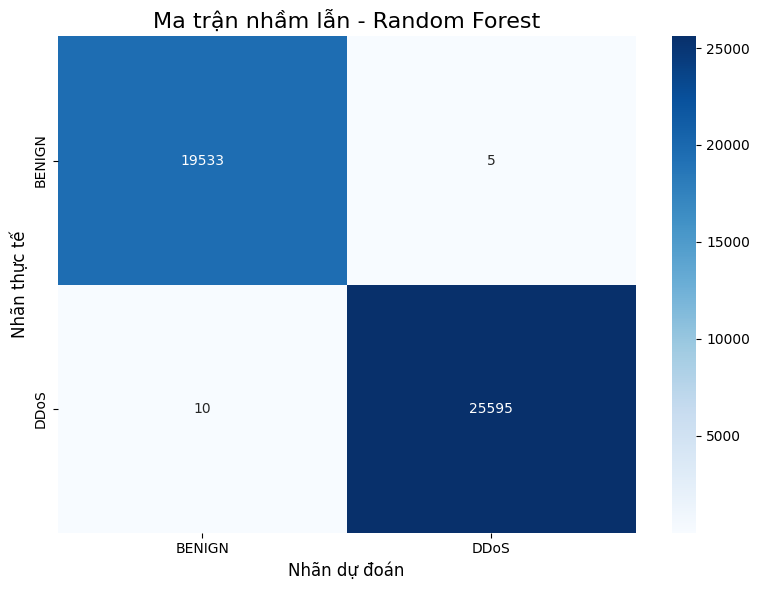

--- KẾT THÚC ĐÁNH GIÁ ---


In [7]:
print("--- ĐÁNH GIÁ MÔ HÌNH ---")

start_time = time.time()
y_pred = rf_model.predict(X_test_scaled)
pred_time = time.time() - start_time

# Tính các metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nĐộ chính xác (Accuracy): {accuracy:.4f}")
print(f"Thời gian dự đoán: {pred_time:.4f} giây")

print("\nBáo cáo phân loại:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Ma trận nhầm lẫn - Random Forest', fontsize=16)
plt.xlabel('Nhãn dự đoán', fontsize=12)
plt.ylabel('Nhãn thực tế', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("--- KẾT THÚC ĐÁNH GIÁ ---")

## 7. Export model và các file liên quan

In [8]:
print("--- EXPORT MÔ HÌNH VÀ CÁC FILE LIÊN QUAN ---")

# Tạo thư mục output nếu chưa tồn tại
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Export model
model_path = os.path.join(OUTPUT_DIR, MODEL_FILE)
joblib.dump(rf_model, model_path)
print(f"✓ Đã lưu model: {model_path}")

# Export scaler
scaler_path = os.path.join(OUTPUT_DIR, SCALER_FILE)
joblib.dump(scaler, scaler_path)
print(f"✓ Đã lưu scaler: {scaler_path}")

# Export feature names
features_path = os.path.join(OUTPUT_DIR, FEATURES_FILE)
joblib.dump(X.columns.tolist(), features_path)
print(f"✓ Đã lưu danh sách features: {features_path}")

# Export label encoder
le_path = os.path.join(OUTPUT_DIR, LABEL_ENCODER_FILE)
joblib.dump(le, le_path)
print(f"✓ Đã lưu label encoder: {le_path}")

print("\n--- EXPORT HOÀN TẤT ---")
print(f"\nTổng cộng 4 file đã được lưu vào: {os.path.abspath(OUTPUT_DIR)}")

--- EXPORT MÔ HÌNH VÀ CÁC FILE LIÊN QUAN ---
✓ Đã lưu model: ./rf_ddos_model.pkl
✓ Đã lưu scaler: ./rf_scaler.pkl
✓ Đã lưu danh sách features: ./rf_features.pkl
✓ Đã lưu label encoder: ./rf_label_encoder.pkl

--- EXPORT HOÀN TẤT ---

Tổng cộng 4 file đã được lưu vào: /home/dathv2004/Documents/BKDN/Learning/PBL6/network_monitor/v2/src/models/ddos_detector


## 8. Kiểm tra load model

In [9]:
print("--- KIỂM TRA LOAD MODEL ---")

# Load lại các file
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)
loaded_le = joblib.load(le_path)

print("✓ Load model thành công!")
print(f"✓ Số features: {len(loaded_features)}")
print(f"✓ Classes: {loaded_le.classes_}")

# Test với một vài mẫu
sample_indices = np.random.choice(len(X_test), 5, replace=False)
X_sample = X_test.iloc[sample_indices]
X_sample_scaled = loaded_scaler.transform(X_sample)
predictions = loaded_model.predict(X_sample_scaled)
predictions_labels = loaded_le.inverse_transform(predictions)

print("\nKiểm tra dự đoán trên 5 mẫu ngẫu nhiên:")
for i, (pred, true_val) in enumerate(zip(predictions_labels, y_test.iloc[sample_indices])):
    true_label = loaded_le.inverse_transform([true_val])[0]
    print(f"  Mẫu {i+1}: Dự đoán = {pred}, Thực tế = {true_label}")

print("\n--- KIỂM TRA HOÀN TẤT ---")

--- KIỂM TRA LOAD MODEL ---
✓ Load model thành công!
✓ Số features: 20
✓ Classes: ['BENIGN' 'DDoS']

Kiểm tra dự đoán trên 5 mẫu ngẫu nhiên:
  Mẫu 1: Dự đoán = DDoS, Thực tế = DDoS
  Mẫu 2: Dự đoán = DDoS, Thực tế = DDoS
  Mẫu 3: Dự đoán = BENIGN, Thực tế = BENIGN
  Mẫu 4: Dự đoán = BENIGN, Thực tế = BENIGN
  Mẫu 5: Dự đoán = DDoS, Thực tế = DDoS

--- KIỂM TRA HOÀN TẤT ---


## Tóm tắt

Model Random Forest đã được huấn luyện và export thành công!

**Các file đã tạo:**
1. `rf_ddos_model.pkl` - Model Random Forest đã huấn luyện
2. `rf_scaler.pkl` - StandardScaler để chuẩn hóa dữ liệu
3. `rf_features.pkl` - Danh sách các features theo đúng thứ tự
4. `rf_label_encoder.pkl` - LabelEncoder để chuyển đổi nhãn

**Cách sử dụng trong production:**
```python
import joblib
import pandas as pd

# Load các file
model = joblib.load('rf_ddos_model.pkl')
scaler = joblib.load('rf_scaler.pkl')
features = joblib.load('rf_features.pkl')
label_encoder = joblib.load('rf_label_encoder.pkl')

# Chuẩn bị dữ liệu mới (DataFrame với các cột trong 'features')
# new_data = pd.DataFrame(...)

# Chuẩn hóa
new_data_scaled = scaler.transform(new_data[features])

# Dự đoán
predictions = model.predict(new_data_scaled)
predictions_labels = label_encoder.inverse_transform(predictions)
```